In [140]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from torch.utils.data import Dataset, DataLoader

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

WORDS    = ['one','two','three','four','five','six','seven','eight','nine','ten']
PAD      = '<PAD>'
SOS      = '<SOS>'
EOS      = '<EOS>'
vocab    = [PAD, SOS, EOS] + WORDS
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx[PAD]
SOS_IDX    = word2idx[SOS]
EOS_IDX    = word2idx[EOS]

def make_pair(seq_len=None):
    if seq_len is None:
        seq_len = random.randint(3, 7)  # slightly harder than Day 17
    words = random.sample(WORDS, seq_len)
    src   = [word2idx[w] for w in words]
    tgt   = [SOS_IDX] + [word2idx[w] for w in reversed(words)] + [EOS_IDX]
    return src, tgt, words  

def collate_fn(batch):
    srcs, tgts, _ = zip(*batch)
    max_src = max(len(s) for s in srcs)
    max_tgt = max(len(t) for t in tgts)
    srcs_padded = torch.tensor([s + [PAD_IDX]*(max_src-len(s)) for s in srcs])
    tgts_padded = torch.tensor([t + [PAD_IDX]*(max_tgt-len(t)) for t in tgts])
    return srcs_padded, tgts_padded

class ReversalDataset(Dataset):
    def __init__(self, n):
        self.pairs = [make_pair() for _ in range(n)]
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx): return self.pairs[idx]

dataset    = ReversalDataset(10000)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

Using device: mps


In [141]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.W_s = nn.Linear(hidden_size, hidden_size, bias = False)        # Decoder
        self.W_h = nn.Linear(hidden_size, hidden_size, bias = False)        # Encoder 
        self.v = nn.Linear(hidden_size , 1, bias = False)                   # Combined
    
    def forward(self, decoder_hidden, encoder_outputs):
        s = self.W_s(decoder_hidden).unsqueeze(1)
        h = self.W_h(encoder_outputs)
        energy = self.v(torch.tanh(s+h)).squeeze(2)
        attn_weights = F.softmax(energy, dim = 1)

        context = torch.bmm(
            attn_weights.unsqueeze(1), encoder_outputs
        ).squeeze(1)
        return context, attn_weights

In [142]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_size, hidden_size, num_layers,
                                 batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
    
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (h_n, c_n) = self.lstm(embedded)
        return outputs, h_n, c_n                                            # Main difference b/w Seq2Seq

class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(hidden_size)
        self.lstm = nn.LSTM(
            embed_size + hidden_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout   = nn.Dropout(dropout)
    
    def forward(self, token, h, c, encoder_outputs):
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        query = h[-1]
        context, attn_weights = self.attention(query, encoder_outputs)
        lstm_input = torch.cat(
            [embedded, context.unsqueeze(1)], dim=2
        )

        output, (h,c) = self.lstm(lstm_input, (h, c))
        prediction = self.fc(output.squeeze(1))

        return prediction, h, c, attn_weights

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, tgt, teacher_forcing_ratio = 0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]

        outputs = torch.zeros(batch_size, tgt_len, VOCAB_SIZE).to(device)
        all_attentions = []
        encoder_outputs, h, c = self.encoder(src)
        dec_input = tgt[:, 0]

        for t in range(1, tgt_len):
            pred, h, c, attn_weights = self.decoder(dec_input, h, c, encoder_outputs)
            outputs[:, t, :] = pred
            all_attentions.append(attn_weights.detach().cpu())

            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t] if use_teacher else pred.argmax(dim=1)
        return outputs, all_attentions

In [143]:
EMBED_SIZE  = 64
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.3
EPOCHS      = 50
LR          = 0.001
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
random.seed(SEED)
import numpy as np
np.random.seed(SEED)

# also add this for MPS/CUDA reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

encoder = Encoder(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
decoder = AttentionDecoder(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
model   = Seq2SeqAttention(encoder, decoder).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

optimizer    = optim.Adam(model.parameters(), lr=LR)
criterion    = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    teacher_ratio = max(0.0, 0.7 - epoch * 0.02) 

    for src_batch, tgt_batch in dataloader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        optimizer.zero_grad()
        output, _ = model(src_batch, tgt_batch, teacher_forcing_ratio=teacher_ratio)
        
        output_flat = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
        tgt_flat    = tgt_batch[:, 1:].reshape(-1)
        loss = criterion(output_flat, tgt_flat)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f}")

Total trainable parameters: 564,621
Epoch 01/50 | Loss: 1.3693
Epoch 02/50 | Loss: 0.2214
Epoch 03/50 | Loss: 0.0563
Epoch 04/50 | Loss: 0.0217
Epoch 05/50 | Loss: 0.0144
Epoch 06/50 | Loss: 0.0118
Epoch 07/50 | Loss: 0.0169
Epoch 08/50 | Loss: 0.0042
Epoch 09/50 | Loss: 0.0070
Epoch 10/50 | Loss: 0.0031
Epoch 11/50 | Loss: 0.0013
Epoch 12/50 | Loss: 0.0015
Epoch 13/50 | Loss: 0.0206
Epoch 14/50 | Loss: 0.0078
Epoch 15/50 | Loss: 0.0011
Epoch 16/50 | Loss: 0.0004
Epoch 17/50 | Loss: 0.0046
Epoch 18/50 | Loss: 0.0045
Epoch 19/50 | Loss: 0.0019
Epoch 20/50 | Loss: 0.0003
Epoch 21/50 | Loss: 0.0003
Epoch 22/50 | Loss: 0.0010
Epoch 23/50 | Loss: 0.0083
Epoch 24/50 | Loss: 0.0181
Epoch 25/50 | Loss: 0.0030
Epoch 26/50 | Loss: 0.0004
Epoch 27/50 | Loss: 0.0002
Epoch 28/50 | Loss: 0.0003
Epoch 29/50 | Loss: 0.0003
Epoch 30/50 | Loss: 0.0001
Epoch 31/50 | Loss: 0.0012
Epoch 32/50 | Loss: 0.0035
Epoch 33/50 | Loss: 0.0008
Epoch 34/50 | Loss: 0.0004
Epoch 35/50 | Loss: 0.0128
Epoch 36/50 | Loss:

In [ ]:
'''def translate_beam(model, src_words, beam_size=3, max_len=10):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([[word2idx[w] for w in src_words]]).to(device)
        encoder_outputs, h, c = model.encoder(src)

        beams = [(0.0, [], torch.tensor([SOS_IDX]).to(device), h, c)]
        completed = []

        for _ in range(max_len):
            if not beams:   # all beams completed
                break
            new_beams = []
            for score, tokens, dec_input, h, c in beams:
                pred, h_new, c_new, _ = model.decoder(
                    dec_input, h, c, encoder_outputs)
                log_probs = torch.log_softmax(pred[0], dim=0)
                top_scores, top_idx = log_probs.topk(beam_size)

                for i in range(beam_size):
                    token_id    = top_idx[i].item()
                    token_score = top_scores[i].item()
                    word        = idx2word[token_id]
                    new_score   = score + token_score

                    if word == EOS:
                        completed.append((new_score, tokens))
                    else:
                        new_beams.append((
                            new_score,
                            tokens + [word],
                            torch.tensor([token_id]).to(device),
                            h_new, c_new
                        ))

            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]
            # ← removed the early break

        if completed:
            best = max(completed, key=lambda x: x[0])
            return best[1]
        return beams[0][1]


test_cases = [
    ['one', 'two', 'three'],
    ['five', 'nine', 'two', 'seven'],
    ['ten', 'four', 'six', 'one', 'eight'],
]

for src_words in test_cases:
    predicted = translate_beam(model, src_words)
    expected     = list(reversed(src_words))
    correct      = "✅" if predicted == expected else "❌"
    print(f"  Input:    {src_words}")
    print(f"  Expected: {expected}")
    print(f"  Got:      {predicted}  {correct}")
    print()'''

  Input:    ['one', 'two', 'three']
  Expected: ['three', 'two', 'one']
  Got:      ['three', 'two', 'one']  ✅

  Input:    ['five', 'nine', 'two', 'seven']
  Expected: ['seven', 'two', 'nine', 'five']
  Got:      ['seven', 'two', 'nine', 'five']  ✅

  Input:    ['ten', 'four', 'six', 'one', 'eight']
  Expected: ['eight', 'one', 'six', 'four', 'ten']
  Got:      ['eight', 'one', 'one', 'four', 'ten']  ❌



In [145]:
def translate_with_attention(model, src_words, max_len=10):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([[word2idx[w] for w in src_words]]).to(device)
        encoder_outputs, h, c = model.encoder(src)

        dec_input  = torch.tensor([SOS_IDX]).to(device)
        result     = []
        attentions = []
        last_token = None

        for _ in range(max_len):
            pred, h, c, attn_weights = model.decoder(dec_input, h, c, encoder_outputs)

            # applying penalty
            if last_token is not None:
                pred[0][last_token] = float('-inf')
            top_token = pred.argmax(dim=1)
            word = idx2word[top_token.item()]

            if word == EOS:
                break

            result.append(word)
            attentions.append(attn_weights.squeeze(0).cpu().numpy())
            last_token = top_token.item()   # ← update last_token
            dec_input = top_token

    return result, attentions
    
test_cases = [
    ['one', 'two', 'three'],
    ['five', 'nine', 'two', 'seven'],
    ['ten', 'four', 'six', 'one', 'eight'],
]

for src_words in test_cases:
    predicted, _ = translate_with_attention(model, src_words)
    expected     = list(reversed(src_words))
    correct      = "✅" if predicted == expected else "❌"
    print(f"  Input:    {src_words}")
    print(f"  Expected: {expected}")
    print(f"  Got:      {predicted}  {correct}")
    print()

  Input:    ['one', 'two', 'three']
  Expected: ['three', 'two', 'one']
  Got:      ['three', 'two', 'one']  ✅

  Input:    ['five', 'nine', 'two', 'seven']
  Expected: ['seven', 'two', 'nine', 'five']
  Got:      ['seven', 'two', 'nine', 'five']  ✅

  Input:    ['ten', 'four', 'six', 'one', 'eight']
  Expected: ['eight', 'one', 'six', 'four', 'ten']
  Got:      ['eight', 'one', 'six', 'four', 'ten']  ✅




Attention visualization:
  Input:  ['three', 'one', 'four', 'two', 'five']
  Output: ['five', 'two', 'four', 'one', 'three']


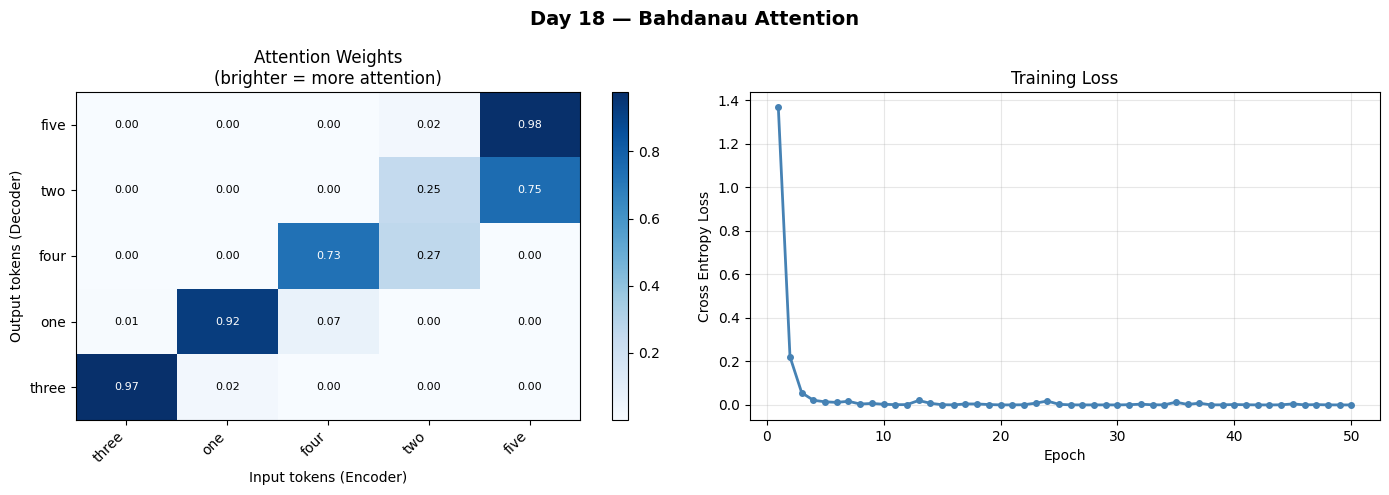

Plot saved as day18_attention.png


In [147]:
def plot_attention(src_words, predicted, attentions):
    """
    Rows    = output tokens (what decoder generated)
    Columns = input tokens  (what encoder saw)
    Bright cell = high attention weight
    """
    attn_matrix = np.array(attentions)  # (tgt_len, src_len)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Day 18 — Bahdanau Attention', fontsize=14, fontweight='bold')

    # Attention heatmap
    im = axes[0].imshow(attn_matrix, cmap='Blues', aspect='auto')
    axes[0].set_xticks(range(len(src_words)))
    axes[0].set_xticklabels(src_words, rotation=45, ha='right')
    axes[0].set_yticks(range(len(predicted)))
    axes[0].set_yticklabels(predicted)
    axes[0].set_xlabel('Input tokens (Encoder)')
    axes[0].set_ylabel('Output tokens (Decoder)')
    axes[0].set_title('Attention Weights\n(brighter = more attention)')
    plt.colorbar(im, ax=axes[0])

    # Annotate cells with weight values
    for i in range(len(predicted)):
        for j in range(len(src_words)):
            axes[0].text(j, i, f'{attn_matrix[i, j]:.2f}',
                        ha='center', va='center', fontsize=8,
                        color='white' if attn_matrix[i, j] > 0.5 else 'black')

    # Training loss
    axes[1].plot(range(1, EPOCHS+1), train_losses,
                 color='steelblue', linewidth=2, marker='o', markersize=4)
    axes[1].set_title('Training Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Cross Entropy Loss')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('day18_attention.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved as day18_attention.png")

viz_src   = ['three', 'one', 'four', 'two', 'five']
viz_pred, viz_attn = translate_with_attention(model, viz_src)
print(f"\nAttention visualization:")
print(f"  Input:  {viz_src}")
print(f"  Output: {viz_pred}")

if viz_attn:
    plot_attention(viz_src, viz_pred, viz_attn)
else:
    print("  (Model output empty — try retraining or increasing epochs)")




In [146]:
'''def plot_attention(src_words, predicted, attentions):
    """
    Rows    = output tokens (what decoder generated)
    Columns = input tokens  (what encoder saw)
    Bright cell = high attention weight
    """
    attn_matrix = np.array(attentions)  # (tgt_len, src_len)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Day 18 — Bahdanau Attention', fontsize=14, fontweight='bold')

    # Attention heatmap
    im = axes[0].imshow(attn_matrix, cmap='Blues', aspect='auto')
    axes[0].set_xticks(range(len(src_words)))
    axes[0].set_xticklabels(src_words, rotation=45, ha='right')
    axes[0].set_yticks(range(len(predicted)))
    axes[0].set_yticklabels(predicted)
    axes[0].set_xlabel('Input tokens (Encoder)')
    axes[0].set_ylabel('Output tokens (Decoder)')
    axes[0].set_title('Attention Weights\n(brighter = more attention)')
    plt.colorbar(im, ax=axes[0])

    for i in range(len(predicted)):
        for j in range(len(src_words)):
            axes[0].text(j, i, f'{attn_matrix[i, j]:.2f}',
                        ha='center', va='center', fontsize=8,
                        color='white' if attn_matrix[i, j] > 0.5 else 'black')

    # Training loss
    axes[1].plot(range(1, EPOCHS+1), train_losses,
                 color='steelblue', linewidth=2, marker='o', markersize=4)
    axes[1].set_title('Training Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Cross Entropy Loss')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('day18_attention.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved as day18_attention.png")

viz_src = ['three', 'one', 'four', 'two', 'five']

# using beam search for the prediction
viz_pred = translate_beam(model, viz_src)

# collecting attention weights in a separate pass (greedy, just for visualization)
model.eval()
with torch.no_grad():
    src = torch.tensor([[word2idx[w] for w in viz_src]]).to(device)
    encoder_outputs, h, c = model.encoder(src)
    dec_input = torch.tensor([SOS_IDX]).to(device)
    viz_attn = []

    for _ in range(len(viz_pred)):
        pred, h, c, attn_weights = model.decoder(dec_input, h, c, encoder_outputs)
        viz_attn.append(attn_weights.squeeze(0).cpu().numpy())
        dec_input = torch.tensor([word2idx[w] for w in [viz_pred[len(viz_attn)-1]]]).to(device)

print(f"\nAttention visualization:")
print(f"  Input:  {viz_src}")
print(f"  Output: {viz_pred}")

if viz_attn:
    plot_attention(viz_src, viz_pred, viz_attn)'''


'def plot_attention(src_words, predicted, attentions):\n    """\n    Rows    = output tokens (what decoder generated)\n    Columns = input tokens  (what encoder saw)\n    Bright cell = high attention weight\n    """\n    attn_matrix = np.array(attentions)  # (tgt_len, src_len)\n\n    fig, axes = plt.subplots(1, 2, figsize=(14, 5))\n    fig.suptitle(\'Day 18 — Bahdanau Attention\', fontsize=14, fontweight=\'bold\')\n\n    # Attention heatmap\n    im = axes[0].imshow(attn_matrix, cmap=\'Blues\', aspect=\'auto\')\n    axes[0].set_xticks(range(len(src_words)))\n    axes[0].set_xticklabels(src_words, rotation=45, ha=\'right\')\n    axes[0].set_yticks(range(len(predicted)))\n    axes[0].set_yticklabels(predicted)\n    axes[0].set_xlabel(\'Input tokens (Encoder)\')\n    axes[0].set_ylabel(\'Output tokens (Decoder)\')\n    axes[0].set_title(\'Attention Weights\n(brighter = more attention)\')\n    plt.colorbar(im, ax=axes[0])\n\n    for i in range(len(predicted)):\n        for j in range(len(sr